Dataset Shape: (1000, 11)

Columns:
Index(['TransactionID', 'Date', 'MobileModel', 'Brand', 'Price', 'UnitsSold',
       'TotalRevenue', 'CustomerAge', 'CustomerGender', 'Location',
       'PaymentMethod'],
      dtype='object')

First 5 Rows:
                          TransactionID        Date MobileModel  \
0  79397f68-61ed-4ea8-bcb2-f918d4e6c05b  2024-01-06   direction   
1  4f87d114-f522-4ead-93e3-f336402df6aa  2024-04-05       right   
2  6750b7d6-dcc5-48c5-a76a-b6fc9d540fe1  2024-02-13      summer   
3  7da7de95-f772-4cc2-bce0-b0873f98233e  2024-04-17        keep   
4  469044af-0d60-4d87-af66-c6603e844057  2024-06-02      option   

              Brand    Price  UnitsSold  TotalRevenue  CustomerAge  \
0         Green Inc  1196.95         85      28002.80           32   
1   Thomas-Thompson  1010.34         64       2378.82           55   
2  Sanchez-Williams   400.80         95      31322.56           57   
3    Greer and Sons   338.60         79      31159.75           46   
4  

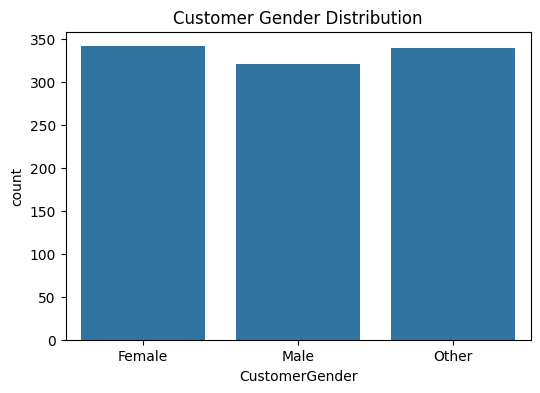

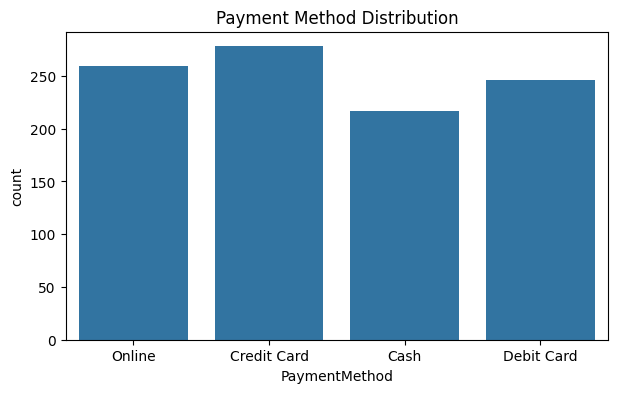

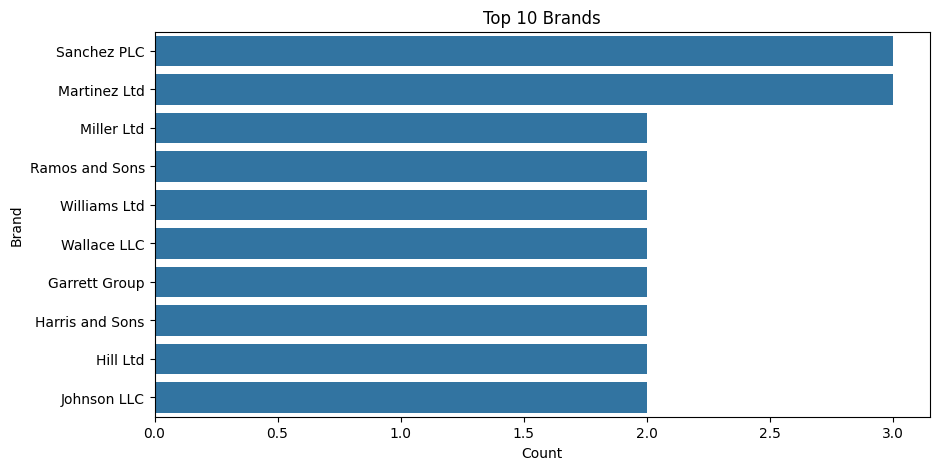

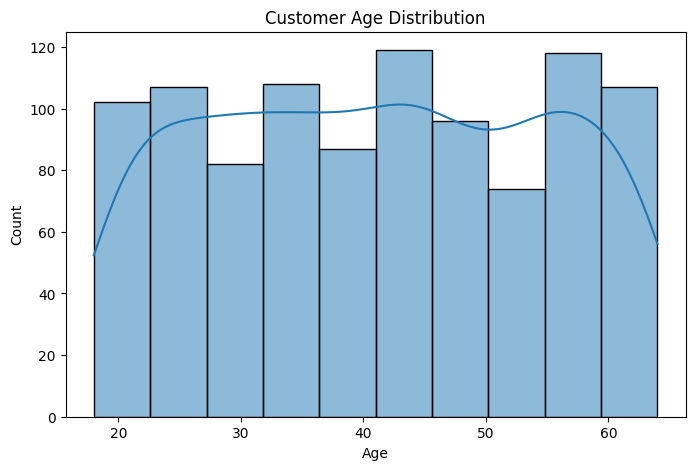

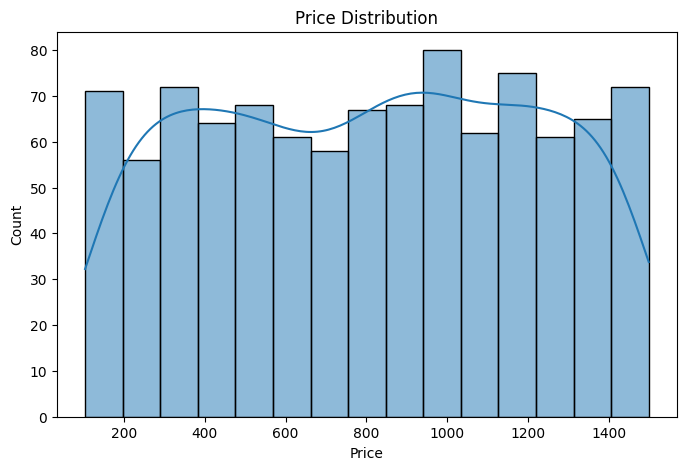

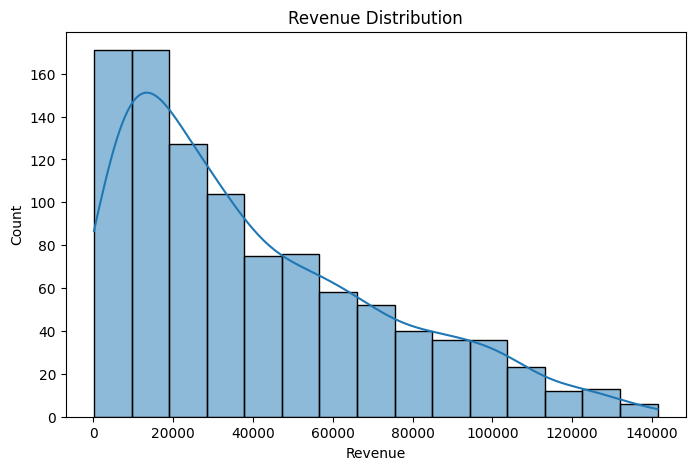

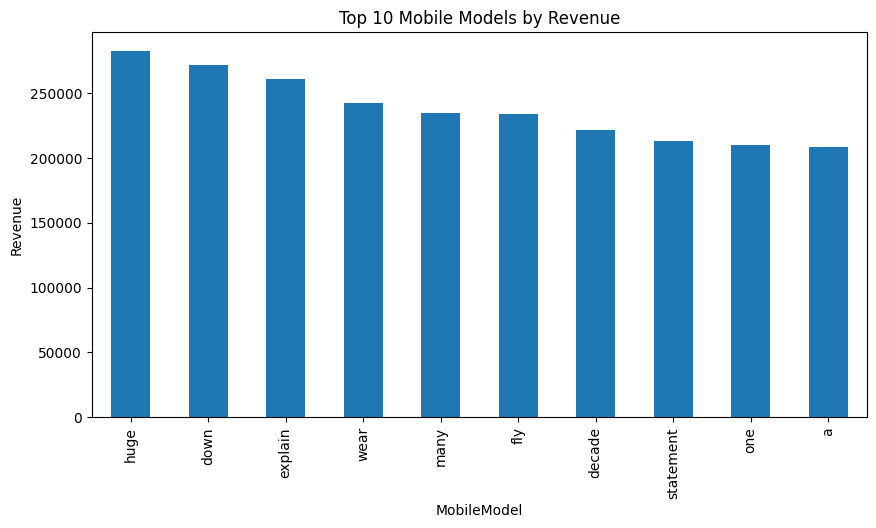

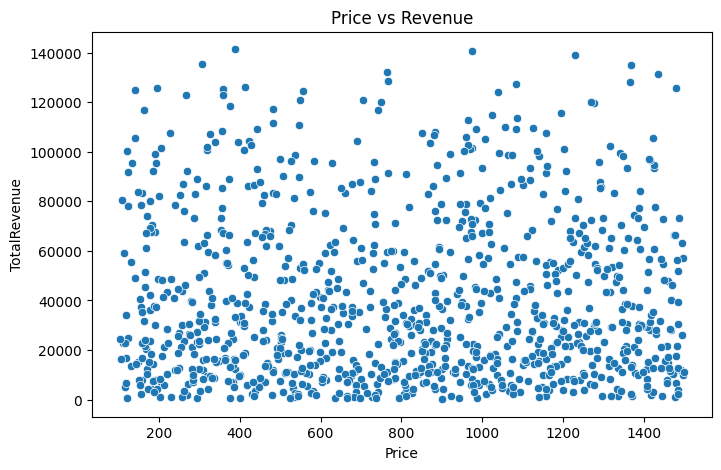

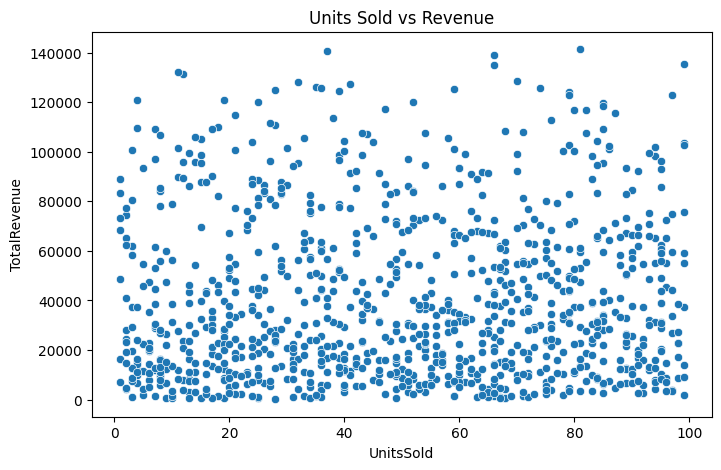

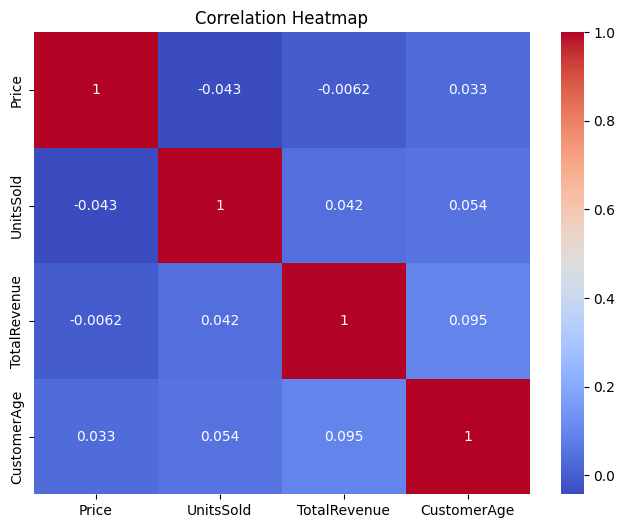


========== KEY INSIGHTS ==========
Most Used Payment Method:
Credit Card

Most Popular Brand:
Sanchez PLC

Average Mobile Price:
807.51

Average Revenue:
40218.45

Average Customer Age:
41.14

Top Revenue Brand:
Johnson LLC


In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/mobile_sales.csv")

# ------------------------------------------
# Basic Information
# ------------------------------------------
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

# ------------------------------------------
# Missing Values
# ------------------------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# ------------------------------------------
# Duplicate Values
# ------------------------------------------
print("\nDuplicate Rows:", df.duplicated().sum())

# ------------------------------------------
# Statistical Summary
# ------------------------------------------
print("\nStatistical Summary:")
print(df.describe())

# ------------------------------------------
# Customer Gender Distribution
# ------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='CustomerGender', data=df)
plt.title('Customer Gender Distribution')
plt.show()

# ------------------------------------------
# Payment Method Distribution
# ------------------------------------------
plt.figure(figsize=(7,4))
sns.countplot(x='PaymentMethod', data=df)
plt.title('Payment Method Distribution')
plt.show()

# ------------------------------------------
# Brand Distribution
# ------------------------------------------
plt.figure(figsize=(10,5))

top_brands = df['Brand'].value_counts().head(10)

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title("Top 10 Brands")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()
# ------------------------------------------
# Customer Age Distribution
# ------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['CustomerAge'],
             bins=10,
             kde=True)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.show()

# ------------------------------------------
# Mobile Price Distribution
# ------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['Price'],
             bins=15,
             kde=True)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.show()

# ------------------------------------------
# Revenue Distribution
# ------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['TotalRevenue'],
             bins=15,
             kde=True)

plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.show()

# ------------------------------------------
# Top 10 Mobile Models by Revenue
# ------------------------------------------
top_models = df.groupby('MobileModel')['TotalRevenue'].sum()\
               .sort_values(ascending=False)\
               .head(10)

plt.figure(figsize=(10,5))
top_models.plot(kind='bar')
plt.title('Top 10 Mobile Models by Revenue')
plt.ylabel('Revenue')
plt.show()

# ------------------------------------------
# Revenue by Brand
# ------------------------------------------
brand_revenue = df.groupby('Brand')['TotalRevenue'].sum()

# ------------------------------------------
# Price vs Revenue
# ------------------------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(x='Price',
                y='TotalRevenue',
                data=df)

plt.title('Price vs Revenue')
plt.show()

# ------------------------------------------
# Units Sold vs Revenue
# ------------------------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(x='UnitsSold',
                y='TotalRevenue',
                data=df)

plt.title('Units Sold vs Revenue')
plt.show()

# ------------------------------------------
# Correlation Heatmap
# ------------------------------------------
numeric_cols = ['Price',
                'UnitsSold',
                'TotalRevenue',
                'CustomerAge']

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

# ------------------------------------------
# Key Insights
# ------------------------------------------
print("\n========== KEY INSIGHTS ==========")

print("Most Used Payment Method:")
print(df['PaymentMethod'].value_counts().idxmax())

print("\nMost Popular Brand:")
print(df['Brand'].value_counts().idxmax())

print("\nAverage Mobile Price:")
print(round(df['Price'].mean(),2))

print("\nAverage Revenue:")
print(round(df['TotalRevenue'].mean(),2))

print("\nAverage Customer Age:")
print(round(df['CustomerAge'].mean(),2))

print("\nTop Revenue Brand:")
print(df.groupby('Brand')['TotalRevenue'].sum().idxmax())